# Figure 4.5: 850-hPa Streamfunction and Wind Regression Subplots (P1, P2, and P2–P1)

This notebook plots the 850-hPa streamfunction regression (shading) and 850-hPa wind regression (vectors) against Niño 3.4 in a three-panel layout: P1 at upper left, P2 at upper right, and the P2–P1 difference at lower center. The colorbars are positioned horizontally beneath their corresponding panels.

### Plot Customization Guide

To change the visualization or plotting data, refer to these variables in the code:

- **`psi_plot_scale`**: Sets the divisor applied to streamfunction regression data before plotting. A value of `1e6` means the colorbar is expressed in `10⁶ m² s⁻¹ per 1σ Niño 3.4`.
- **`levels`** and **`ticks`**: Set the data range, color-contour interval, and colorbar tick locations.
- **`mc_extent`**: Sets the geographical plotting bounds in `[lon_min, lon_max, lat_min, lat_max]` format.
- **`mc_xticks`** and **`mc_yticks`**: Set the longitude and latitude coordinate-label intervals on the maps.
- **`wind_step`**: Sets wind-vector density. A larger value produces fewer vectors.
- **`sig_step`**: Sets significance-marker density. A larger value produces fewer markers.
- **`subplots`** (in the plotting cell): Contains tuples with the plot axis (`ax`), shading data (`psi_reg_*`), vector components (`wind_u_reg_*`, `wind_v_reg_*`), significance mask (`psi_vector_sig_*`), quiver scale, quiver key, and title for each subplot.
- **`gs`** (`GridSpec`): Sets the two-row, four-column layout; panels a and b each span two columns in the upper row, while panel c spans the two central columns in the lower row.
- **`fig.subplots_adjust`** and the manual-layout parameter block: Set margins, panel spacing, colorbar positions, and quiver-key positions.


In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
})

FIG_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Fig4')
CACHE_DIR = FIG_DIR
RESULTS_DIR = FIG_DIR
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
psi_ds = xr.open_dataset(CACHE_DIR / 'psi_reg_cache_1981_2025.nc')
wind_ds = xr.open_dataset(CACHE_DIR / 'wind_reg_cache_1981_2025.nc')

psi_plot_scale = 1e6

# Load variables (P1, P2, and P2-P1 difference)
psi_reg_past = psi_ds['psi_reg_past']
psi_reg_recent = psi_ds['psi_reg_recent']
psi_reg_recent_minus_past = psi_ds['psi_reg_recent_minus_past']

psi_vector_sig_past = psi_ds['psi_vector_sig_past']
psi_vector_sig_recent = psi_ds['psi_vector_sig_recent']
psi_vector_sig_recent_minus_past = psi_ds['psi_vector_sig_recent_minus_past']

wind_u_reg_past = wind_ds['wind_u_reg_past']
wind_u_reg_recent = wind_ds['wind_u_reg_recent']
wind_u_reg_recent_minus_past = wind_ds['wind_u_reg_recent_minus_past']

wind_v_reg_past = wind_ds['wind_v_reg_past']
wind_v_reg_recent = wind_ds['wind_v_reg_recent']
wind_v_reg_recent_minus_past = wind_ds['wind_v_reg_recent_minus_past']

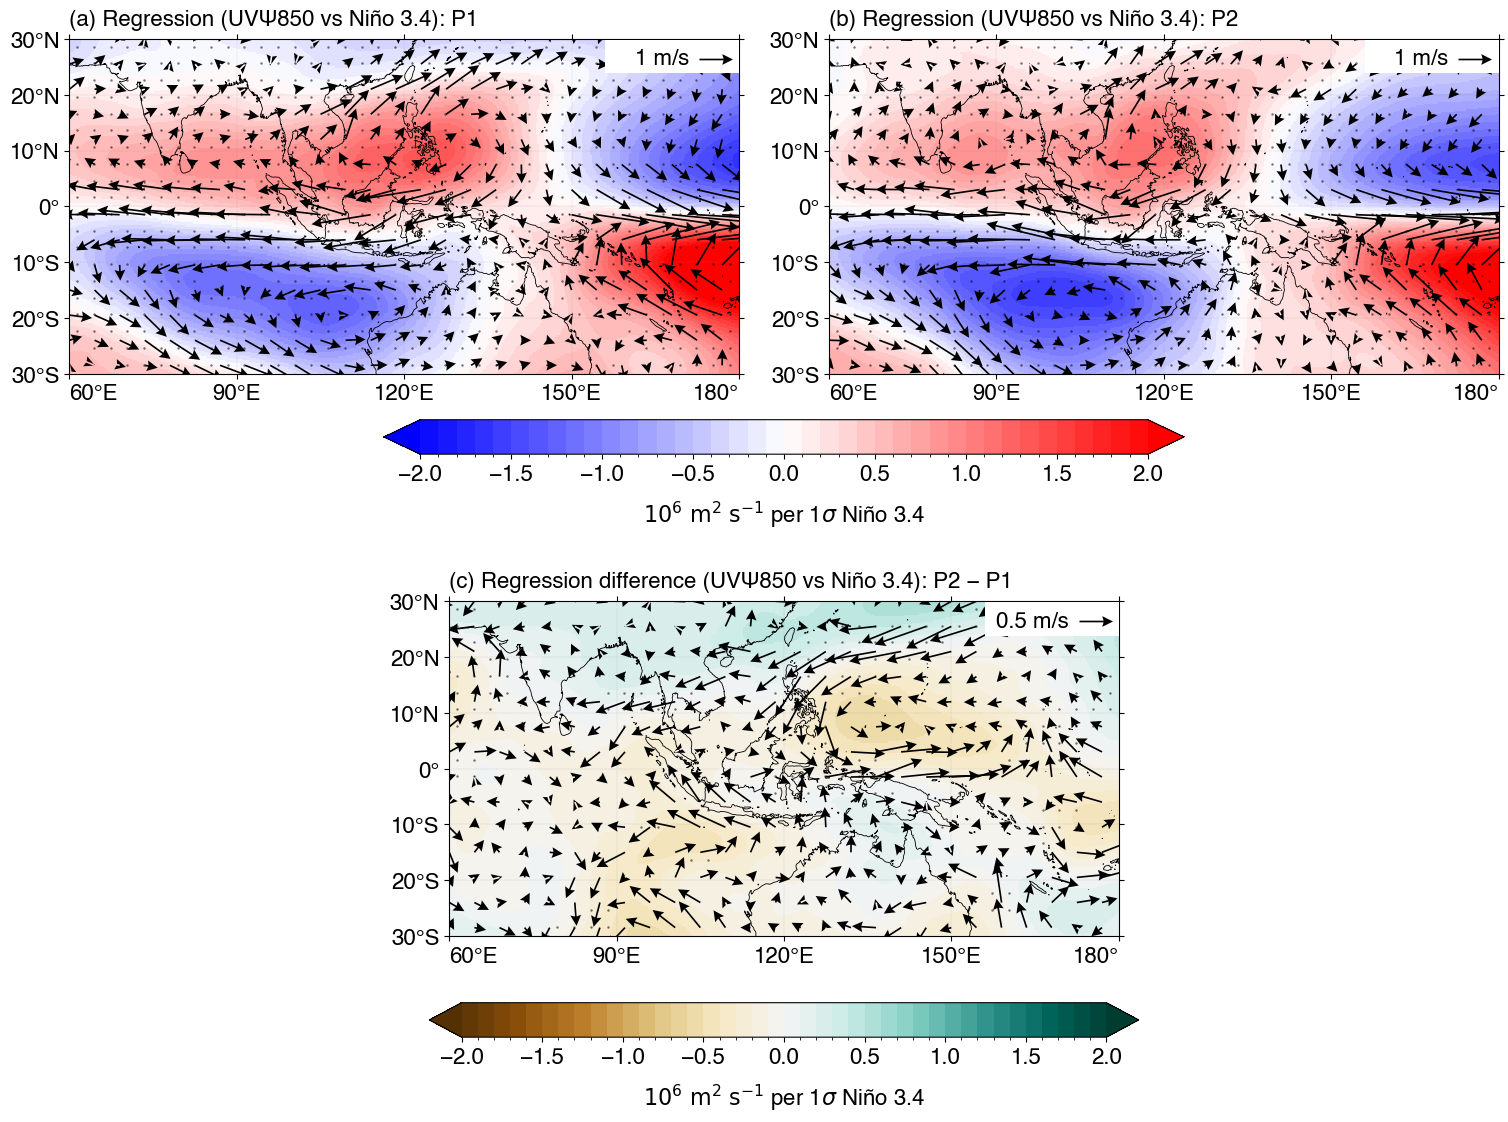

In [3]:
PLOT_FONTSIZE = 16
plt.rcParams.update({
    'font.size': PLOT_FONTSIZE,
    'axes.titlesize': PLOT_FONTSIZE,
    'axes.labelsize': PLOT_FONTSIZE,
    'xtick.labelsize': PLOT_FONTSIZE,
    'ytick.labelsize': PLOT_FONTSIZE,
})

levels = np.arange(-2, 2.0 + 0.1 / 2, 0.1)
ticks = np.arange(-2, 2.0 + 0.5 / 2, 0.5)

mc_extent = [60, 180, -30, 30]
mc_xticks = [60, 90, 120, 150, 180]
mc_yticks = [-30, -20, -10, 0, 10, 20, 30]

wind_step = 18
sig_step = 12

# =========================
# PARAMETER LAYOUT MANUAL
# =========================
# Change the values in this block to adjust the layout without changing the main plotting code.
# All positions and margins use figure-relative coordinates: 0 = left/bottom edge, 1 = right/top edge.

fig_width = 16
fig_height = 11.5

# Horizontal spacing between panels a and b.
# Increase it (for example, 0.025 -> 0.08) if latitude labels or maps are too close.
# Decrease it (for example, 0.025 -> 0.01) to bring panels a and b closer together.
subplot_wspace = 0.2

# Vertical spacing between the upper row and panel c.
# Increase this value to move panel c lower.
# Decrease this value to move panel c closer to panels a and b.
subplot_hspace = 0.68

# Overall figure margins.
# left/right set the left and right edges of all panels.
# bottom/top set the lower and upper space. Increase bottom if the lower colorbar or ticks are clipped.
fig_left = 0.055
fig_right = 0.965
fig_bottom = 0.15
fig_top = 0.93

# Colorbar size and position.
# colorbar_extra_width extends the colorbar beyond the width of panel c.
# Example: 0.00 = the same width as panel c; 0.08 = 8% of the figure wider, split evenly on both sides.
colorbar_extra_width = 0.025

# Vertical distance between the colorbar and panel c.
# Increase this value to move the colorbar lower; decrease it to move it closer to panel c.
colorbar_y_gap = 0.075

# Colorbar thickness. Increase it for a thicker colorbar, for example 0.032 -> 0.045.
colorbar_height = 0.03

# Distance between the unit label and the colorbar.
# Increase colorbar_labelpad if the label is too close to the colorbar ticks.
colorbar_labelpad = 10
streamfunction_cbar_label = r'$10^6\ \mathrm{m}^2\ \mathrm{s}^{-1}$ per 1$\sigma$ Niño 3.4'

# Position the quiver key at upper right, outside the map area to avoid overlapping data.
# The Y value controls the vertical position: a smaller value moves the quiver key lower.
# To move the quiver key lower, reduce quiver_key_y_top and quiver_key_y_bottom.
# Panel c uses a higher Y value because its title is longer.
quiver_key_x_top = 0.94
quiver_key_y_top = 0.90
quiver_key_x_bottom = 0.94
quiver_key_y_bottom = 0.90

fig = plt.figure(figsize=(fig_width, fig_height))
# Two-by-four layout: panels a and b span the upper row; panel c spans the central lower columns.
# wspace uses subplot_wspace above, so change that variable to adjust the a-b spacing.
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=subplot_hspace, wspace=subplot_wspace)

ax1 = fig.add_subplot(gs[0, 0:2], projection=ccrs.PlateCarree(central_longitude=180))
ax2 = fig.add_subplot(gs[0, 2:4], projection=ccrs.PlateCarree(central_longitude=180))
ax3 = fig.add_subplot(gs[1, 1:3], projection=ccrs.PlateCarree(central_longitude=180))

subplots = [
    (ax1, psi_reg_past / psi_plot_scale, wind_u_reg_past, wind_v_reg_past, psi_vector_sig_past, 20, 1.0, '1 m/s', '(a) Regression (UVΨ850 vs Niño 3.4): P1'),
    (ax2, psi_reg_recent / psi_plot_scale, wind_u_reg_recent, wind_v_reg_recent, psi_vector_sig_recent, 20, 1.0, '1 m/s', '(b) Regression (UVΨ850 vs Niño 3.4): P2'),
    (ax3, psi_reg_recent_minus_past / psi_plot_scale, wind_u_reg_recent_minus_past, wind_v_reg_recent_minus_past, psi_vector_sig_recent_minus_past, 10, 0.5, '0.5 m/s', '(c) Regression difference (UVΨ850 vs Niño 3.4): P2 − P1')
]

top_img = None
diff_img = None

for ax, shade_data, u_data, v_data, sig_mask, scale, key_u, key_label, title in subplots:
    # Subset shading coordinates inline (descending latitude)
    lon_vals_s = shade_data['lon'].values
    lat_vals_s = shade_data['lat'].values
    
    if lon_vals_s[0] <= lon_vals_s[-1]:
        shade_sub = shade_data.sel(lon=slice(60, 180))
    else:
        shade_sub = shade_data.sel(lon=slice(180, 60))
        
    if lat_vals_s[0] <= lat_vals_s[-1]:
        shade_sub = shade_sub.sel(lat=slice(-30, 30))
    else:
        shade_sub = shade_sub.sel(lat=slice(30, -30))

    plot_data = shade_sub.reset_coords(drop=True)
    img = plot_data.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='BrBG' if ax is ax3 else 'bwr',
        levels=levels,
        extend='both',
        add_colorbar=False,
        add_labels=False,
        infer_intervals=True,
    )
    if ax is ax3:
        diff_img = img
    else:
        top_img = img

    # Subset u-wind coordinates inline
    lon_vals_u = u_data['lon'].values
    lat_vals_u = u_data['lat'].values
    
    if lon_vals_u[0] <= lon_vals_u[-1]:
        u_sub = u_data.sel(lon=slice(60, 180))
    else:
        u_sub = u_data.sel(lon=slice(180, 60))
        
    if lat_vals_u[0] <= lat_vals_u[-1]:
        u_sub = u_sub.sel(lat=slice(-30, 30))
    else:
        u_sub = u_sub.sel(lat=slice(30, -30))

    # Subset v-wind coordinates inline
    lon_vals_v = v_data['lon'].values
    lat_vals_v = v_data['lat'].values
    
    if lon_vals_v[0] <= lon_vals_v[-1]:
        v_sub = v_data.sel(lon=slice(60, 180))
    else:
        v_sub = v_data.sel(lon=slice(180, 60))
        
    if lat_vals_v[0] <= lat_vals_v[-1]:
        v_sub = v_sub.sel(lat=slice(-30, 30))
    else:
        v_sub = v_sub.sel(lat=slice(30, -30))

    # Downsample wind vectors for the quiver plot
    u_plot = u_sub.isel(lat=slice(None, None, wind_step), lon=slice(None, None, wind_step))
    v_plot = v_sub.isel(lat=slice(None, None, wind_step), lon=slice(None, None, wind_step))

    q = ax.quiver(
        u_plot['lon'].values,
        u_plot['lat'].values,
        u_plot.values,
        v_plot.values,
        transform=ccrs.PlateCarree(),
        scale=scale,
        scale_units='width',
        width=0.0025,
        headwidth=8 * (0.0020 / 0.0025),
        headlength=8 * (0.0020 / 0.0025),
        headaxislength=7 * (0.0020 / 0.0025),
        minshaft=0,
        minlength=0,
        color='black',
        zorder=4,
    )
    
    # To move the quiver key lower, reduce key_y.
    key_x = quiver_key_x_top if ax in [ax1, ax2] else quiver_key_x_bottom
    key_y = quiver_key_y_top if ax in [ax1, ax2] else quiver_key_y_bottom
    # White reference-key box in the upper-right map corner.
    # The rectangle dimensions and location are specified as axes fractions.
    key_box = mpatches.Rectangle(
        (0.8, 0.8975), 0.2, 0.10,
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='none',
        alpha=1,
        zorder=5,
    )
    ax.add_patch(key_box)
    qk = ax.quiverkey(
        q,
        X=key_x,
        Y=0.94,
        U=key_u,
        label=key_label,
        labelpos='W',
        coordinates='axes',
        color='black',
        fontproperties={'size': PLOT_FONTSIZE, 'weight': 'bold'},
        labelsep=0.1,
    )
    qk.set_zorder(6)
    qk.text.set_zorder(7)

    # Plot the significance mask inline
    if sig_mask is not None:
        # Subset the significance mask inline
        lon_vals_sig = sig_mask['lon'].values
        lat_vals_sig = sig_mask['lat'].values
        
        sig_sub = sig_mask.fillna(False).astype(np.int8)
        if lon_vals_sig[0] <= lon_vals_sig[-1]:
            sig_sub = sig_sub.sel(lon=slice(60, 180))
        else:
            sig_sub = sig_sub.sel(lon=slice(180, 60))
            
        if lat_vals_sig[0] <= lat_vals_sig[-1]:
            sig_sub = sig_sub.sel(lat=slice(-30, 30))
        else:
            sig_sub = sig_sub.sel(lat=slice(30, -30))

        sig_plot = sig_sub.coarsen(lat=sig_step, lon=sig_step, boundary='trim').max() > 0
        yy, xx = np.where(sig_plot.values)
        if yy.size > 0:
            ax.scatter(
                sig_plot['lon'].values[xx],
                sig_plot['lat'].values[yy],
                s=12,
                c='k',
                marker='.',
                linewidths=0,
                alpha=0.55,
                transform=ccrs.PlateCarree(),
                zorder=4,
            )

    # Draw the base map inline: use the 50 m coastline and no state borders
    ax.coastlines(resolution='50m', linewidth=0.6, color='black', zorder=3)
    ax.set_extent(mc_extent, crs=ccrs.PlateCarree())
    ax.gridlines(draw_labels=False, xlocs=mc_xticks, ylocs=mc_yticks, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')
    ax.set_xticks(mc_xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(mc_yticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'}))
    ax.yaxis.set_major_formatter(LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'}))
    ax.tick_params(direction='out', top=True, right=True, labelsize=PLOT_FONTSIZE)
    ax.tick_params(labelright=False)
    ax.set_xlabel('')
    ax.set_ylabel('')

    ax.set_title(title, fontsize=PLOT_FONTSIZE, fontweight='bold', loc='left', pad=10)

# Apply the figure margins.
# If left-side text is clipped, increase fig_left slightly.
# If the lower colorbar or ticks are clipped, increase fig_bottom slightly.
fig.subplots_adjust(left=fig_left, right=fig_right, bottom=fig_bottom, top=fig_top)

# Align longitude tick labels
plt.draw()
for ax in [ax1, ax2, ax3]:
    for label in ax.get_xticklabels():
        text = label.get_text()
        if '60' in text:
            label.set_horizontalalignment('left')
        elif '180' in text:
            label.set_horizontalalignment('right')

# P1/P2 colorbar between the upper row and the difference panel.
pos_top_l = ax1.get_position()
pos_top_r = ax2.get_position()
pos_bottom = ax3.get_position()

top_total_width = pos_top_r.x1 - pos_top_l.x0
top_cbar_width = 0.56 * top_total_width
top_cbar_x0 = pos_top_l.x0 + (top_total_width - top_cbar_width) / 2
top_gap = pos_top_l.y0 - pos_bottom.y1
top_cbar_y0 = pos_top_l.y0 - colorbar_height - 0.040

top_cax = fig.add_axes([top_cbar_x0, top_cbar_y0, top_cbar_width, colorbar_height])
top_cbar = fig.colorbar(top_img, cax=top_cax, orientation='horizontal', ticks=ticks, spacing='proportional', extend='both')
top_cbar.set_label(streamfunction_cbar_label, fontsize=PLOT_FONTSIZE, labelpad=colorbar_labelpad)

# P2 − P1 difference colorbar below the difference panel.
diff_cbar_x0 = pos_bottom.x0 - (colorbar_extra_width / 2)
diff_cbar_y0 = pos_bottom.y0 - 0.088
diff_cbar_width = pos_bottom.width + colorbar_extra_width

diff_cax = fig.add_axes([diff_cbar_x0, diff_cbar_y0, diff_cbar_width, colorbar_height])
diff_cbar = fig.colorbar(diff_img, cax=diff_cax, orientation='horizontal', ticks=ticks, spacing='proportional', extend='both')
diff_cbar.set_label(streamfunction_cbar_label, fontsize=PLOT_FONTSIZE, labelpad=colorbar_labelpad)

for _cbar in (top_cbar, diff_cbar):
    _cbar.ax.xaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"{val:.1f}".rstrip('0').rstrip('.') if not np.isclose(val, 0) else '0'))
    _cbar.update_ticks()

for _cbar in (top_cbar, diff_cbar):
    _cbar.ax.tick_params(labelsize=PLOT_FONTSIZE if 'PLOT_FONTSIZE' in globals() else 16)


fig.savefig(RESULTS_DIR / 'streamfunction_wind_reg_subplots.png', dpi=300, bbox_inches='tight')
plt.show()
# plt.close(fig)
